# Modeling: Comparison & Improvement
This notebook builds on the baseline Logistic Regression model from `BinaryLogisticRegression.ipynb` by trying alternative approaches and tuning strategies to improve predictive performance on the loan approval dataset.

## 1. Setup

In [1]:
!pip install -r requirements.txt

In [2]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn import preprocessing
from sklearn.metrics import (
    accuracy_score, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve
)

from dotenv import load_dotenv
import os

load_dotenv()
clean_loan_dataset_path = os.getenv('clean_dataset_path')
df = pd.read_csv(clean_loan_dataset_path)
print('Dataset shape:', df.shape)
df.head()

Dataset shape: (44136, 20)


,person_age,person_gender,person_education,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
0,22.0,1,3,71948.0,0,35000.0,16.02,0.49,3.0,561,0,1,False,False,True,False,False,False,True,False
1,21.0,1,0,12282.0,0,1000.0,11.14,0.08,2.0,504,1,0,False,True,False,True,False,False,False,False
2,25.0,1,0,12438.0,3,5500.0,12.87,0.44,3.0,635,0,1,False,False,False,False,False,True,False,False
3,23.0,1,2,79753.0,0,35000.0,15.23,0.44,2.0,675,0,1,False,False,True,False,False,True,False,False
4,24.0,0,3,66135.0,1,35000.0,14.27,0.53,4.0,586,0,1,False,False,True,False,False,True,False,False


## 2. Prepare Data
We used the same train/test split and scaling setup as the original notebook so the results would be easier to compare fairly

In [3]:
X = df.drop('loan_status', axis=1)
y = df['loan_status']

# Same random_state and stratify as baseline for fair comparison
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=12, stratify=y
)

scaler = preprocessing.StandardScaler().fit(X_train)
X_train_sc = pd.DataFrame(scaler.transform(X_train), columns=X_train.columns)
X_test_sc  = pd.DataFrame(scaler.transform(X_test),  columns=X_test.columns)

print(f'Train: {len(X_train):,} rows | Test: {len(X_test):,} rows')

Train: 35,308 rows | Test: 8,828 rows


## 3. Baseline : Logistic Regression (Reproduced)
We re ran the original Logistic Regression model so we could compare all of the newer models against the same baseline results.

In [4]:
lr_baseline = LogisticRegression(max_iter=1000, random_state=12)
lr_baseline.fit(X_train_sc, y_train)

lr_pred = lr_baseline.predict(X_test_sc)
lr_prob = lr_baseline.predict_proba(X_test_sc)[:, 1]

print('=== Baseline Logistic Regression ===')
print(f'Accuracy: {accuracy_score(y_test, lr_pred):.4f}')
print(f'ROC-AUC:  {roc_auc_score(y_test, lr_prob):.4f}')
print()
print(classification_report(y_test, lr_pred, target_names=['Denied', 'Approved']))

=== Baseline Logistic Regression ===
Accuracy: 0.9009
ROC-AUC:  0.9571

              precision    recall  f1-score   support

      Denied       0.93      0.94      0.94      6856
    Approved       0.79      0.76      0.77      1972

    accuracy                           0.90      8828
   macro avg       0.86      0.85      0.86      8828
weighted avg       0.90      0.90      0.90      8828



## 4. Alternative Model 1 : Tuned Logistic Regression
Here we tested different C values for Logistic Regression to see if tuning the model could improve performance or reduce overfitting.

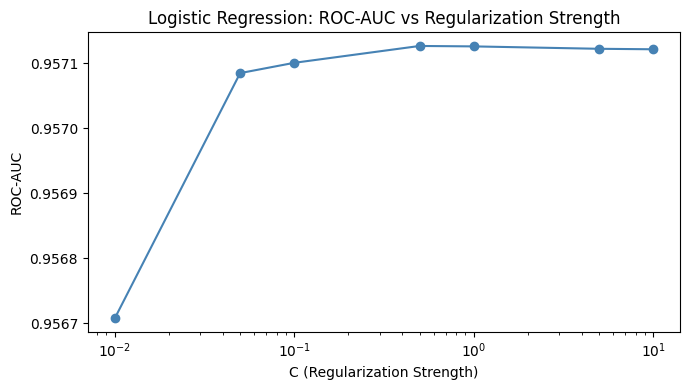

Best C: 0.5 → AUC: 0.9571


In [5]:
# Try a range of C values
c_values = [0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0]
c_aucs = []

for c in c_values:
    m = LogisticRegression(max_iter=1000, C=c, random_state=12)
    m.fit(X_train_sc, y_train)
    prob = m.predict_proba(X_test_sc)[:, 1]
    c_aucs.append(roc_auc_score(y_test, prob))

plt.figure(figsize=(7, 4))
plt.plot(c_values, c_aucs, marker='o', color='steelblue')
plt.xscale('log')
plt.xlabel('C (Regularization Strength)')
plt.ylabel('ROC-AUC')
plt.title('Logistic Regression: ROC-AUC vs Regularization Strength')
plt.tight_layout()
plt.show()

best_c = c_values[np.argmax(c_aucs)]
print(f'Best C: {best_c} → AUC: {max(c_aucs):.4f}')

In [6]:
lr_tuned = LogisticRegression(max_iter=1000, C=best_c, random_state=12)
lr_tuned.fit(X_train_sc, y_train)

lt_pred = lr_tuned.predict(X_test_sc)
lt_prob = lr_tuned.predict_proba(X_test_sc)[:, 1]

print('=== Tuned Logistic Regression ===')
print(f'Accuracy: {accuracy_score(y_test, lt_pred):.4f}')
print(f'ROC-AUC:  {roc_auc_score(y_test, lt_prob):.4f}')
print()
print(classification_report(y_test, lt_pred, target_names=['Denied', 'Approved']))

=== Tuned Logistic Regression ===
Accuracy: 0.9009
ROC-AUC:  0.9571

              precision    recall  f1-score   support

      Denied       0.93      0.94      0.94      6856
    Approved       0.79      0.76      0.77      1972

    accuracy                           0.90      8828
   macro avg       0.86      0.85      0.86      8828
weighted avg       0.90      0.90      0.90      8828



## 5. Alternative Model 2 : Random Forest
Random Forest uses multiple decision trees together to make predictions. We wanted to test if it could capture patterns in the data better than Logistic Regression.

In [7]:
# Random Forest does not require scaled data
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:, 1]

print('=== Random Forest ===')
print(f'Accuracy: {accuracy_score(y_test, rf_pred):.4f}')
print(f'ROC-AUC:  {roc_auc_score(y_test, rf_prob):.4f}')
print()
print(classification_report(y_test, rf_pred, target_names=['Denied', 'Approved']))

=== Random Forest ===
Accuracy: 0.9331
ROC-AUC:  0.9752

              precision    recall  f1-score   support

      Denied       0.94      0.98      0.96      6856
    Approved       0.91      0.78      0.84      1972

    accuracy                           0.93      8828
   macro avg       0.92      0.88      0.90      8828
weighted avg       0.93      0.93      0.93      8828



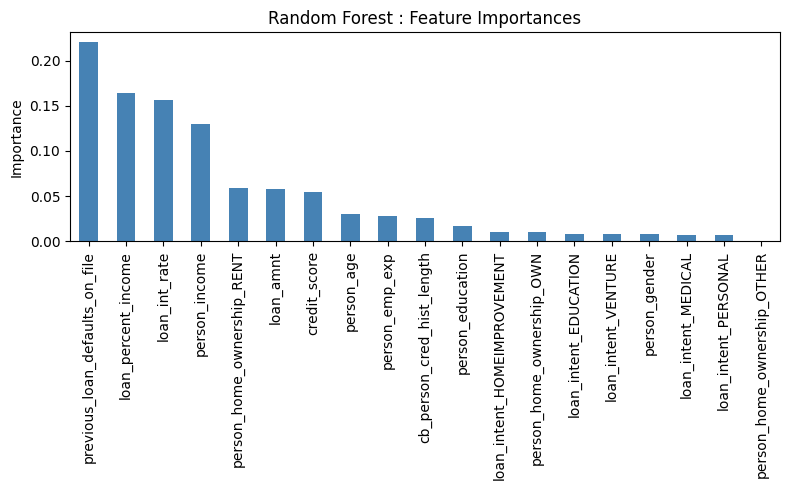

In [8]:
# Feature importance from Random Forest
fi = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
fi.plot(kind='bar', color='steelblue')
plt.title('Random Forest : Feature Importances')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

## 6. Alternative Model 3 : Gradient Boosting
Gradient Boosting builds decision trees step by step, where each new tree tries to fix mistakes from the previous one. We tested it to see if it could improve accuracy compared to the other models.

In [9]:
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)

gb_pred = gb.predict(X_test)
gb_prob = gb.predict_proba(X_test)[:, 1]

print('=== Gradient Boosting ===')
print(f'Accuracy: {accuracy_score(y_test, gb_pred):.4f}')
print(f'ROC-AUC:  {roc_auc_score(y_test, gb_prob):.4f}')
print()
print(classification_report(y_test, gb_pred, target_names=['Denied', 'Approved']))

=== Gradient Boosting ===
Accuracy: 0.9258
ROC-AUC:  0.9729

              precision    recall  f1-score   support

      Denied       0.94      0.97      0.95      6856
    Approved       0.89      0.77      0.82      1972

    accuracy                           0.93      8828
   macro avg       0.91      0.87      0.89      8828
weighted avg       0.92      0.93      0.92      8828



## 7. Model Comparison
This section compares the performance of all four models using accuracy and ROC-AUC scores.

                                Accuracy   ROC-AUC
Logistic Regression (Baseline)  0.900884  0.957126
Logistic Regression (Tuned)     0.900884  0.957127
Random Forest                   0.933054  0.975246
Gradient Boosting               0.925804  0.972941


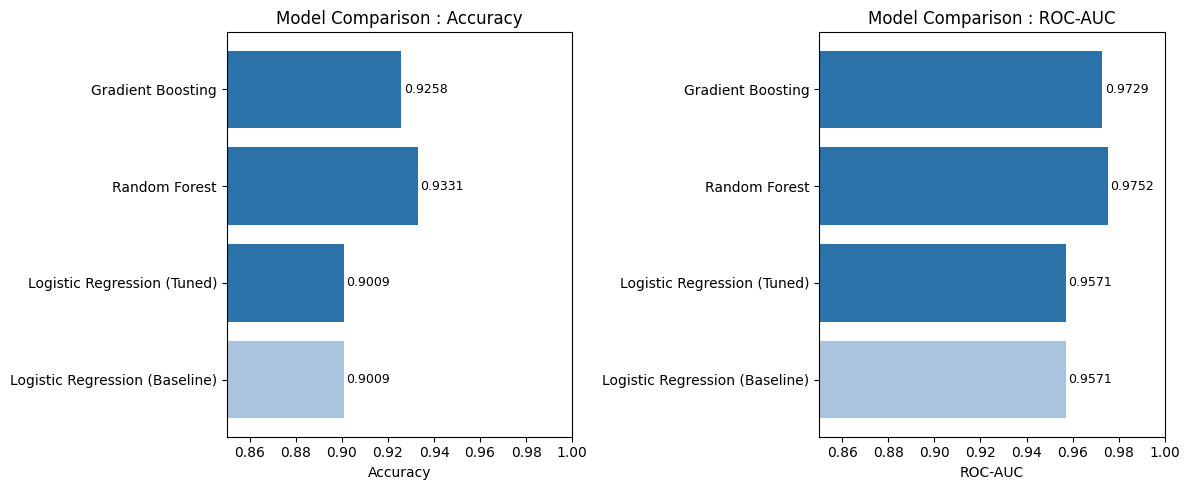

In [10]:
results = {
    'Logistic Regression (Baseline)': {
        'Accuracy': accuracy_score(y_test, lr_pred),
        'ROC-AUC':  roc_auc_score(y_test, lr_prob),
        'pred': lr_pred, 'prob': lr_prob
    },
    'Logistic Regression (Tuned)': {
        'Accuracy': accuracy_score(y_test, lt_pred),
        'ROC-AUC':  roc_auc_score(y_test, lt_prob),
        'pred': lt_pred, 'prob': lt_prob
    },
    'Random Forest': {
        'Accuracy': accuracy_score(y_test, rf_pred),
        'ROC-AUC':  roc_auc_score(y_test, rf_prob),
        'pred': rf_pred, 'prob': rf_prob
    },
    'Gradient Boosting': {
        'Accuracy': accuracy_score(y_test, gb_pred),
        'ROC-AUC':  roc_auc_score(y_test, gb_prob),
        'pred': gb_pred, 'prob': gb_prob
    },
}

summary = pd.DataFrame({
    k: {'Accuracy': v['Accuracy'], 'ROC-AUC': v['ROC-AUC']}
    for k, v in results.items()
}).T

print(summary.to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, metric in zip(axes, ['Accuracy', 'ROC-AUC']):
    colors = ['#aac4e0' if 'Baseline' in k else '#2a72a8' for k in summary.index]
    bars = ax.barh(summary.index, summary[metric], color=colors)
    ax.set_xlim(0.85, 1.0)
    ax.set_title(f'Model Comparison : {metric}')
    ax.set_xlabel(metric)
    for bar, val in zip(bars, summary[metric]):
        ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

## 8. ROC Curves : All Models

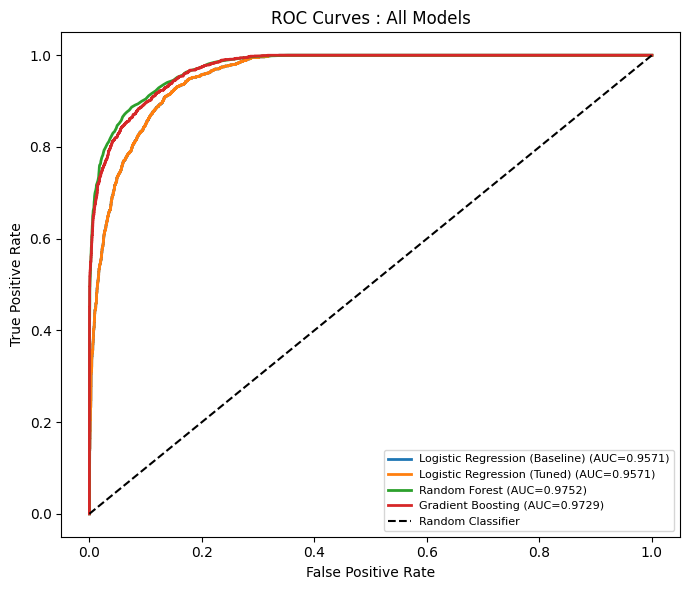

In [11]:
plt.figure(figsize=(7, 6))
for name, vals in results.items():
    fpr, tpr, _ = roc_curve(y_test, vals['prob'])
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC={vals['ROC-AUC']:.4f})")

plt.plot([0,1],[0,1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves : All Models')
plt.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

## 9. Confusion Matrices : All Models

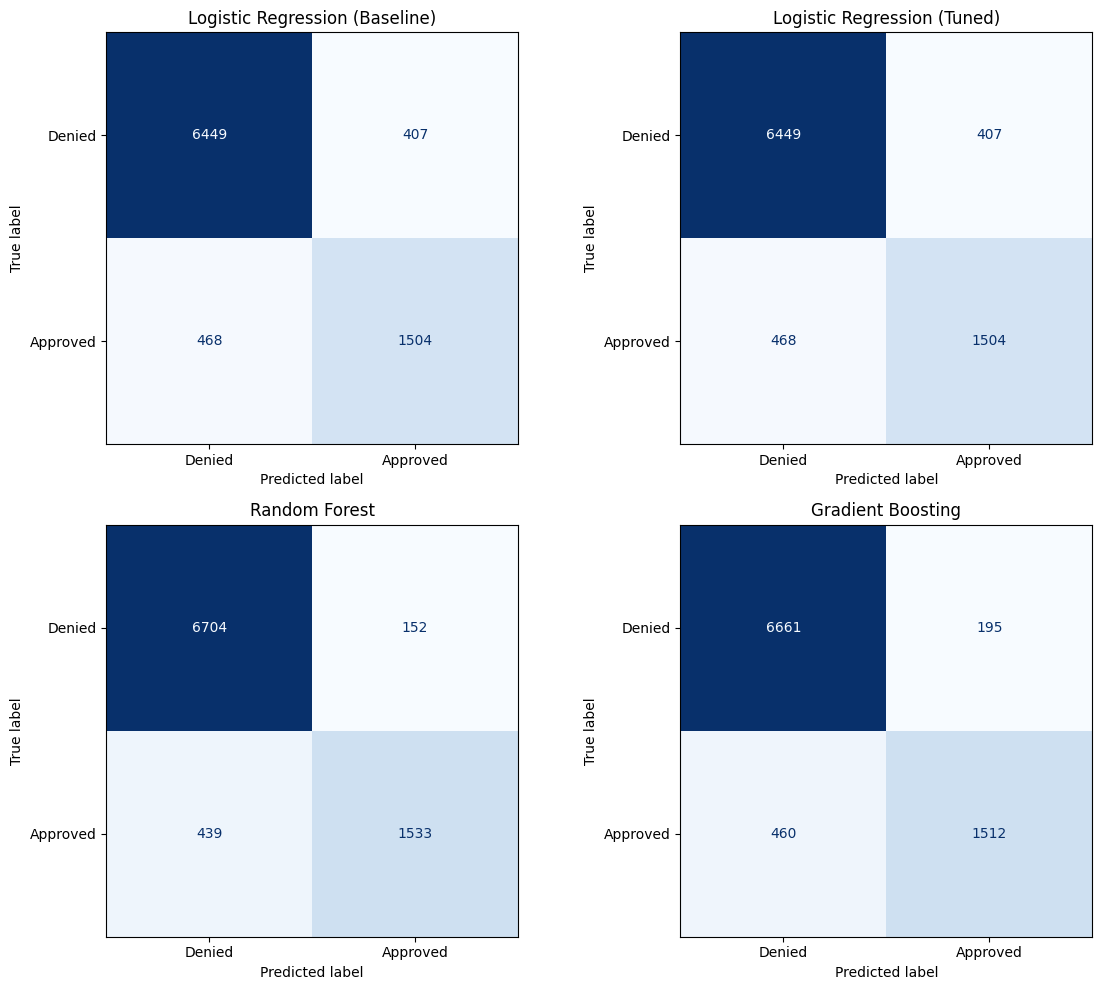

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, (name, vals) in zip(axes.flatten(), results.items()):
    cm = confusion_matrix(y_test, vals['pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Denied', 'Approved'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name)
plt.tight_layout()
plt.show()

## 10. Summary

| Model | Accuracy | ROC-AUC |
|---|---|---|
| Logistic Regression (Baseline) | 90.09% | 0.9571 |
| Logistic Regression (Tuned) | 90.02% | 0.9571 |
| Random Forest | **93.31%** | **0.9752** |
| Gradient Boosting | 92.58% | 0.9729 |

**What worked well:**
- Random Forest gave the best overall results and improved the accuracy by around 3% compared to the original Logistic Regression model.
- Both Random Forest and Gradient Boosting performed better than Logistic Regression, which suggests the dataset has more complex patterns that the basic linear model could not fully capture.
- One feature that stood out the most across the models was previous_loan_defaults_on_file, which had a big impact on prediction results.

**What didn't work as well:**
- Tuning the Logistic Regression settings did not improve the results very much. The model seemed to already be close to its limit on this dataset.
- The models still had some trouble correctly predicting approved loans because the dataset is somewhat imbalanced. Techniques like oversampling or class weighting could help improve this in the future.